In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator)
from cartopy.io import shapereader
import geopandas
import itertools

from ari_exceedance_map_functions_pub import *

In [7]:
first_year = 1981
#first_year = 2002
#first_year = 2018

last_year = 2023
#last_year = 2025

years = np.arange(first_year,last_year)

years_qpe = np.arange(years[0],2025)
#years_qpe = np.arange(2002,2025)

years_mrms = np.arange(2018,2025)

longnames = {"stage4":"NCEP Stage IV", 
             "mrms": "MRMS",
            "prism": "PRISM",
            "cocorahs": "CoCoRaHS",
            "conus404": "CONUS404"}

In [11]:
datasets = ['prism','conus404']
#datasets = ['stage4','mrms']

aris = ['1000']
durations = ['24','48','72']

lists = [aris,
         durations,
        datasets]

combos=[]
for element in itertools.product(*lists):
    combos = combos + [element]

combos_str = []
for combo in combos:
    res = ' '.join(combo)
    combos_str = combos_str + [res]

combos_str


['1000 24 prism',
 '1000 24 conus404',
 '1000 48 prism',
 '1000 48 conus404',
 '1000 72 prism',
 '1000 72 conus404']

In [12]:
### highlight WA/OR in a different color since there's no data
ari_grid = xr.open_dataset("/glade/campaign/univ/ucsu0118/atlas14/allusa_ari_1000yr_24hr_xarray_prismgrid.nc")['precip']
ari_grid_withpnw = xr.open_dataset("/glade/campaign/univ/ucsu0118/atlas14/allusa_ari_100yr_24hr_xarray_prismgrid.nc")['precip']

ari_pnw = xr.where((ari_grid.isnull()) & (ari_grid_withpnw > 0), 1, np.nan)

lon2d, lat2d = np.meshgrid(ari_pnw.lon, ari_pnw.lat)


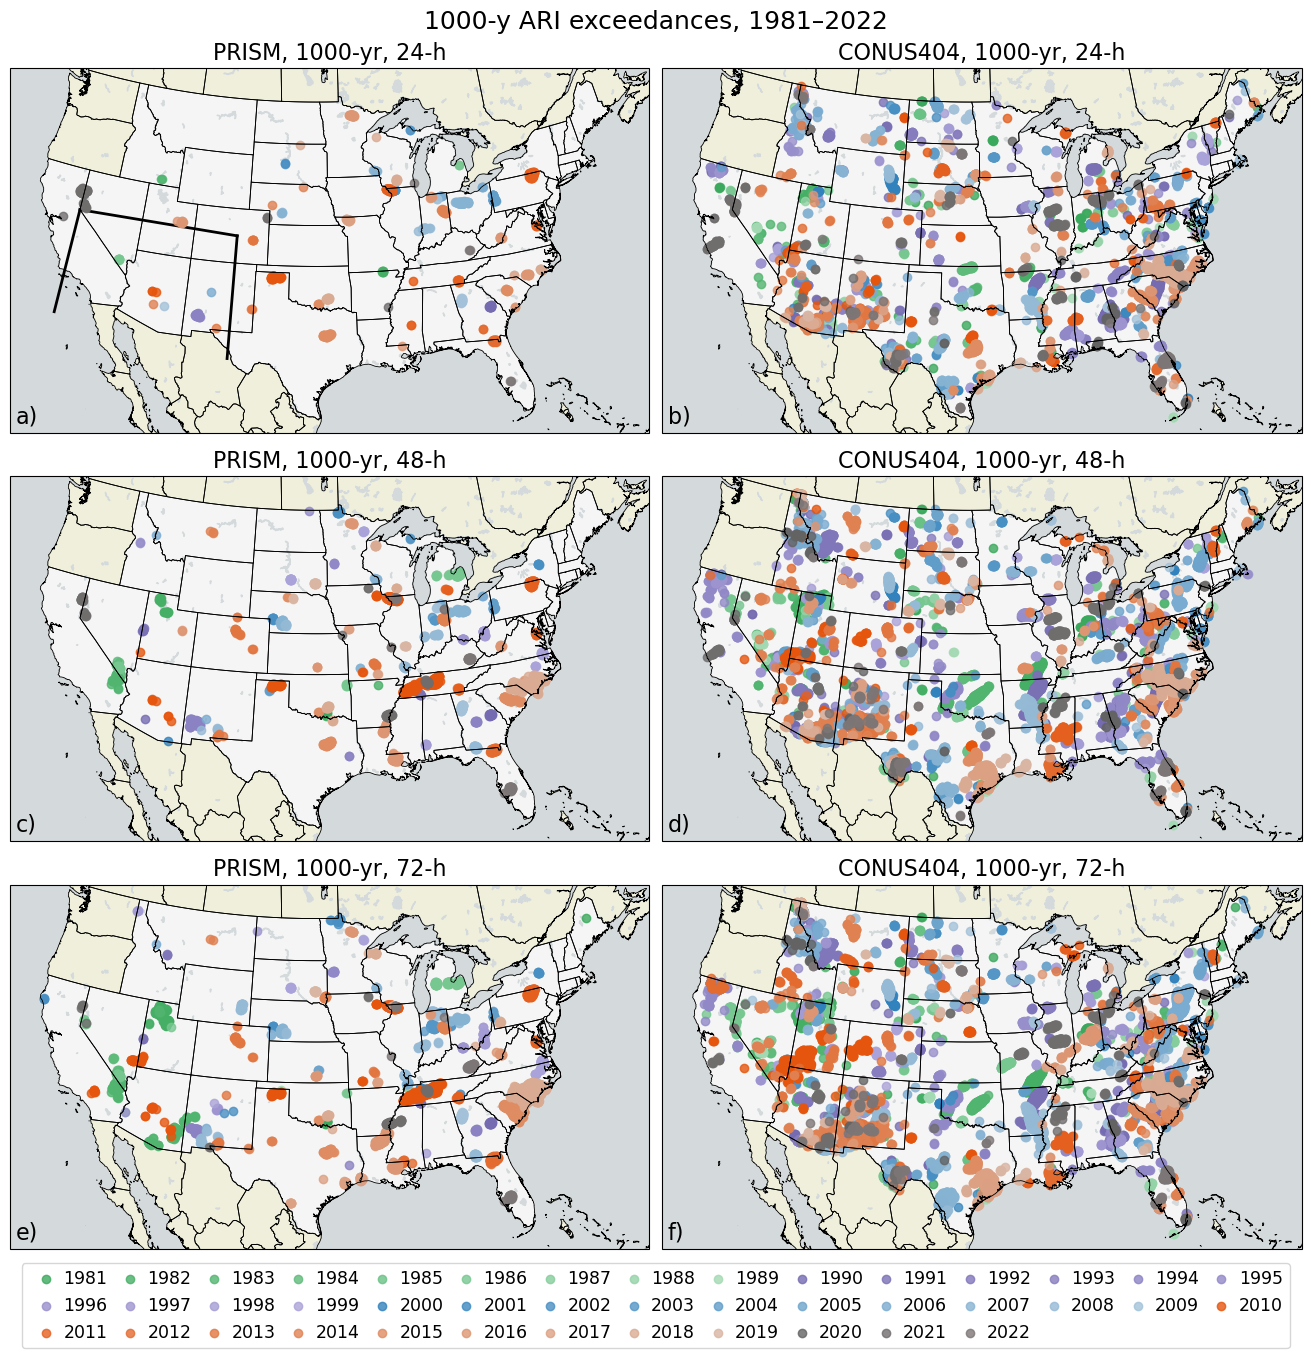

In [18]:
### create multi-panel figure with subplot mosaic

crs = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=35)

panel_letter = 'a'
counter = 0

if first_year==1981:
    figsize=(13,13.5)
else:
    figsize=(13,13.2)

fig, ax_dict = plt.subplot_mosaic( 
        [combos_str[0:2],
         combos_str[2:4],
         combos_str[4:6],
        ],
            figsize=figsize, 
            constrained_layout=True,
            subplot_kw={'projection': crs})

axlist=[]  ### this is for the overall colorbar
for k, ax in ax_dict.items():
    plot_background(ax,-121.,-72.,22.1,49.1)
    axlist=axlist+[ax]

### gray out places with no ARI
for combo in combos_str:

    dataset = combo.split(' ')[2]
    ari = int(combo.split(' ')[0])
    duration = int(combo.split(' ')[1])

    if dataset=="conus404":
        if duration > 24:
            data_all = pd.read_csv(dataset+"/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit_nooverlaps.csv")
        else:
            data_all = pd.read_csv(dataset+"/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit.csv")
    elif dataset=="mrms":
        if duration > 24:
            data_all = pd.read_csv(dataset+"/"+dataset+"_"+str(years_mrms[0])+'-'+str(years_mrms[-1])+"_events_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit_nooverlaps.csv")
        else:
            data_all = pd.read_csv(dataset+"/"+dataset+"_"+str(years_mrms[0])+'-'+str(years_mrms[-1])+"_events_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit.csv")
    else:
        if duration > 24:
            data_all = pd.read_csv(dataset+"/"+dataset+"_"+str(years_qpe[0])+'-'+str(years_qpe[-1])+"_events_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit_nooverlaps.csv")
        else:
            data_all = pd.read_csv(dataset+"/"+dataset+"_"+str(years_qpe[0])+'-'+str(years_qpe[-1])+"_events_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit.csv")

    data_all['time'] = pd.to_datetime(data_all['time'])
    
    ax_dict[combo].contourf(lon2d, lat2d, ari_pnw, [0,10000000],
            colors=[(0.9375,0.9375, 0.859375),'transparent'], 
            transform=ccrs.PlateCarree())

    for year in range(first_year,last_year):
        data_this = data_all[data_all.time.dt.year==year]

        sc1 = ax_dict[combo].scatter(data_this.lon, data_this.lat, 
                                         color=color_dict[str(year)], label=year,
                                         alpha=0.8,
                                         zorder=4,
                    transform=ccrs.PlateCarree())       

    ### add outline of SW region in first panel
    #if combo==combos_str[0]:
    #    cp = ax_dict[combo].plot([240.0,255.0],[39.0,39.0],color='black', linewidth=2.,  
    #                 markersize=3,transform=ccrs.PlateCarree())
    #    cp = ax_dict[combo].plot([255.0,255.0],[30.,39.0],color='black', linewidth=2., 
    #                 markersize=3,transform=ccrs.PlateCarree())
    #    cp = ax_dict[combo].plot([240.0,240.0],[31.3,39.0],color='black', linewidth=2., 
    #                 markersize=3,transform=ccrs.PlateCarree())

    ###panel title
    ax_dict[combo].set_title(longnames[dataset]+", "+str(ari)+"-yr, "+str(duration)+"-h",
                             fontsize=16)

    ### add panel label
    label = chr(ord(panel_letter) + counter)
    ax_dict[combo].annotate(
        label+")",
        xy=(0, 0), xycoords='axes fraction',
        xytext=(+0.25, +1.25), textcoords='offset fontsize',
        fontsize=16, verticalalignment='top',
        bbox=dict(facecolor='none', edgecolor='none', pad=2.0))
    
    counter += 1

# Create legend at bottom
handles, labels = ax_dict[combos_str[0]].get_legend_handles_labels()
add_fig_legend(fig, handles, labels, n_cols=15, fontsize=12.5)

plt.suptitle(str(ari)+"-y ARI exceedances, "+str(years[0])+"\u2013"+str(years[-1]),
            fontsize=18)

plt.savefig("exceedances_"+str(ari)+"y_"+datasets[0]+"_"+datasets[1]+"_"+str(years[0])+"-"+str(years[-1])+".png")

plt.show()
plt.close('all')